In [1]:
import pandas as pd
import os
import ast
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import datetime
import requests

In [5]:
raw_regional_profiles = {}
hourly_demand_path = "../eia_data_cleaner/data/regional/raw_inputs"
for fname in os.listdir(hourly_demand_path):
    fpath = os.path.join(hourly_demand_path, fname)
    if os.path.isdir(fpath):
        continue
    df = (
        pd.read_csv(fpath, parse_dates=["date_time"])
        .rename(columns={'date_time': 'timestamp', 'demand (MW)': 'value'})
        .set_index("timestamp")
        [["value"]]
    )
    region = fname.replace('.csv', '')
    raw_regional_profiles[region] = df

imputed_regional_profiles = {}
hourly_demand_path = "../eia_data_cleaner/data/regional/outputs"
for fname in os.listdir(hourly_demand_path):
    fpath = os.path.join(hourly_demand_path, fname)
    if os.path.isdir(fpath):
        continue
    df = (
        pd.read_csv(fpath, parse_dates=["date_time"])
        .rename(columns={'date_time': 'timestamp', 'cleaned demand (MW)': 'value'})
        .set_index("timestamp")
        [["value"]]
    )
    region = fname.replace('.csv', '')
    imputed_regional_profiles[region] = df

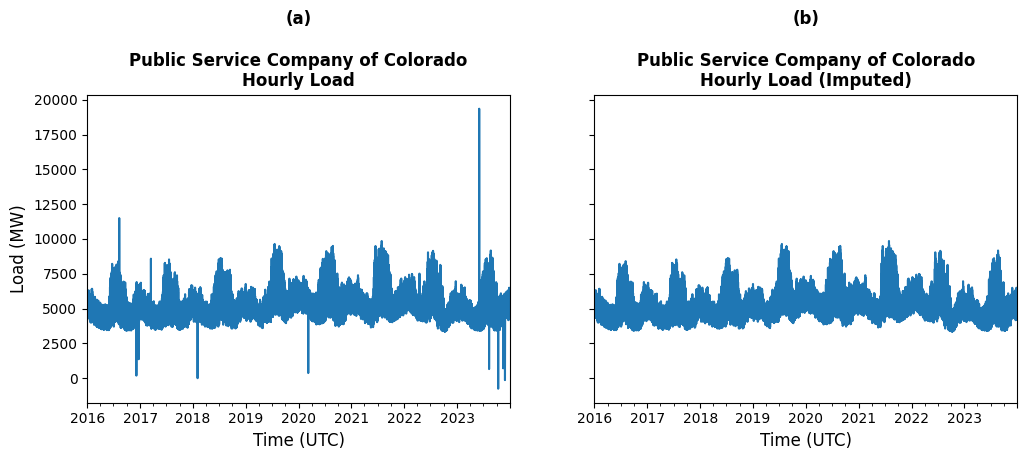

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

raw_regional_profiles['PSCO'].plot(ax=ax[0], legend=False)
ax[0].set_title('(a)\n\nPublic Service Company of Colorado\nHourly Load', fontweight='bold')
ax[0].set_xlabel('Time (UTC)', fontsize=12)
ax[0].set_ylabel('Load (MW)', fontsize=12)


imputed_regional_profiles['PSCO'].plot(ax=ax[1], legend=False)
ax[1].set_title('(b)\n\nPublic Service Company of Colorado\nHourly Load (Imputed)', fontweight='bold')
ax[1].set_xlabel('Time (UTC)', fontsize=12)

# plt.show()
plt.savefig('imputation_example.png', dpi=300, bbox_inches='tight')